# Spiking Poisson Diffusion for Audio Denoising

## Overview

This notebook implements a diffusion-inspired audio denoising framework using Spiking Neural Networks (SNNs).

The objective is to investigate whether spike-based temporal neural dynamics can learn to estimate and reverse stochastic corruption applied to audio waveforms.

The implementation combines:

- Poisson spike noise
- timestep-conditioned denoising
- temporal spike processing
- diffusion-style noise prediction

---

## Objectives

- Implement a stochastic forward corruption process for audio waveforms
- Train a spiking neural network to predict injected corruption
- Evaluate denoising performance using reconstruction error
- Analyze temporal spike-based denoising behavior

---

## Motivation

Diffusion models learn to reverse gradual corruption processes by predicting injected noise at arbitrary timesteps.

Spiking Neural Networks provide a temporally dynamic and biologically inspired computational framework based on discrete spike events and membrane dynamics.

This work explores whether diffusion-style denoising objectives can be learned using spike-based neural processing.

---

## Scope

This implementation focuses on:

- noise prediction
- denoising behavior
- temporal spike processing

The notebook does not implement a full iterative diffusion sampling pipeline.

# Environment Setup

This section initializes the libraries required for:

- audio processing
- neural network training
- spike-based computation
- visualization

PyTorch is used for deep learning operations and snnTorch is used for spiking neural network components.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

from torch.utils.data import DataLoader, Subset

import snntorch as snn
from snntorch import spikegen, surrogate

# Parameter Configuration

This section defines:

- waveform dimensions
- diffusion configuration
- SNN simulation steps
- training parameters
- device configuration

In [2]:
L = 4000

diffusion_steps = 100
num_steps = 20

epochs = 25
batch_size = 64

sr = 16000
MAX_RATE = 0.85

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cpu


# Forward Corruption Process

This section defines the stochastic corruption process used during training.

The corruption pipeline includes:

1. timestep-dependent signal decay
2. conversion to spike firing rates
3. Poisson stochastic sampling
4. Gaussian perturbation

The function returns:

- a noisy waveform
- the actual corruption added to the signal

The model is later trained to predict:

ε = xt - x0

where:

- x0 = clean waveform
- xt = noisy waveform

In [3]:
def get_poisson_spike_noised_sample(x0, t):
    """Returns noisy version + actual noise added"""

    t = t.view(-1, 1).to(DEVICE)

    gamma = torch.exp(
        -0.04 * t.float() * 7 / diffusion_steps
    )

    clean_rate = torch.clamp(
        x0 * gamma * MAX_RATE,
        min=1e-4
    )

    poisson_counts = torch.poisson(clean_rate * 12.0)

    noisy_rate = poisson_counts / 12.0

    gaussian_noise = (
        torch.randn_like(noisy_rate)
        * 0.07
        * (1 - gamma)
    )

    noisy = torch.clamp(
        noisy_rate + gaussian_noise,
        0.0,
        1.0
    )

    actual_noise = noisy - x0

    return noisy, actual_noise

# Dataset Preparation

The SpeechCommands dataset is used for evaluating waveform denoising behavior.

This section performs:

- audio loading
- resampling
- mono conversion
- padding/cropping
- waveform normalization

Final waveform shape:

(4000,)

In [4]:
class PoissonSpikeAudioDataset(torch.utils.data.Dataset):

    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):

        waveform, sample_rate, *_ = self.subset[idx]

        if sample_rate != sr:
            waveform = torchaudio.functional.resample(
                waveform,
                sample_rate,
                sr
            )

        waveform = waveform.mean(dim=0)

        if waveform.shape[0] < L:
            waveform = F.pad(
                waveform,
                (0, L - waveform.shape[0])
            )
        else:
            waveform = waveform[:L]

        waveform = (
            waveform - waveform.min()
        ) / (
            waveform.max() - waveform.min() + 1e-8
        )

        return waveform

# Model Architecture

## SpikingPoissonNoisePredictor

The model predicts corruption added to a waveform at a given diffusion timestep.

The processing pipeline is:

noisy waveform
→ timestep conditioning
→ spike encoding
→ temporal SNN processing
→ predicted corruption

The network uses:

- timestep embeddings
- rate-based spike encoding
- Leaky Integrate-and-Fire neurons
- temporal membrane integration

The model predicts:

ε^ ≈ xt - x0

In [5]:
class SpikingPoissonNoisePredictor(nn.Module):

    def __init__(self, input_dim=L, hidden=1024, beta=0.85):
        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.Linear(1, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, input_dim)
        )

        self.fc1 = nn.Linear(input_dim, hidden)

        self.lif1 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc2 = nn.Linear(hidden, hidden)

        self.lif2 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc_out = nn.Linear(hidden, input_dim)

    def forward(self, x_noisy, t):

        t_emb = self.time_mlp(
            t.unsqueeze(-1).float() / diffusion_steps
        )

        x = x_noisy + t_emb

        spk_in = spikegen.rate(
            x,
            num_steps=num_steps
        )

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        output_sum = 0

        for step in range(num_steps):

            cur1 = self.fc1(spk_in[step])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            output_sum += self.fc_out(mem2)

        return torch.tanh(output_sum / num_steps)

# Dataset and Training Setup

This section:

- downloads the SpeechCommands dataset
- creates a smaller training subset
- initializes DataLoader batches
- initializes the model
- defines optimizer and loss function

In [12]:
# ========================= SETUP =========================

os.makedirs("./data", exist_ok=True)

base_dataset = torchaudio.datasets.SPEECHCOMMANDS(
    root="./data",
    download=True
)

subset = Subset(base_dataset, range(800))

dataset = PoissonSpikeAudioDataset(subset)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

model = SpikingPoissonNoisePredictor().to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=7e-4,
    weight_decay=1e-5
)

loss_fn = nn.MSELoss()

# Training Objective

The model is trained to predict corruption added to audio waveforms at randomly sampled diffusion timesteps.

Training flow:

clean waveform
→ forward corruption
→ noisy waveform
→ spike-based prediction
→ noise estimation loss

Mean Squared Error (MSE) is used as the training objective.

In [13]:
# ========================= TRAINING =========================

print("Training Started - Noise Prediction with Poisson Spike Noise...\n")

loss_history = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for x0 in loader:

        x0 = x0.to(DEVICE)

        t = torch.randint(
            0,
            diffusion_steps,
            (x0.shape[0],),
            device=DEVICE
        )

        noisy, actual_noise = get_poisson_spike_noised_sample(x0, t)

        pred_noise = model(noisy, t)

        loss = loss_fn(pred_noise, actual_noise)

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.5f}"
    )

print("\nTraining Completed!")

Training Started - Noise Prediction with Poisson Spike Noise...

Epoch  1/25 | Loss: 0.06343
Epoch  2/25 | Loss: 0.03398
Epoch  3/25 | Loss: 0.03322
Epoch  4/25 | Loss: 0.03297
Epoch  5/25 | Loss: 0.03305
Epoch  6/25 | Loss: 0.03290
Epoch  7/25 | Loss: 0.03265
Epoch  8/25 | Loss: 0.03254
Epoch  9/25 | Loss: 0.03225
Epoch 10/25 | Loss: 0.03221
Epoch 11/25 | Loss: 0.03209
Epoch 12/25 | Loss: 0.03201
Epoch 13/25 | Loss: 0.03200
Epoch 14/25 | Loss: 0.03191
Epoch 15/25 | Loss: 0.03191
Epoch 16/25 | Loss: 0.03182
Epoch 17/25 | Loss: 0.03182
Epoch 18/25 | Loss: 0.03184
Epoch 19/25 | Loss: 0.03189
Epoch 20/25 | Loss: 0.03183
Epoch 21/25 | Loss: 0.03195
Epoch 22/25 | Loss: 0.03180
Epoch 23/25 | Loss: 0.03178
Epoch 24/25 | Loss: 0.03188
Epoch 25/25 | Loss: 0.03189

Training Completed!


# Training Dynamics

The following plot shows the evolution of training loss across epochs.

The objective is to observe whether the model improves its ability to estimate waveform corruption over time.

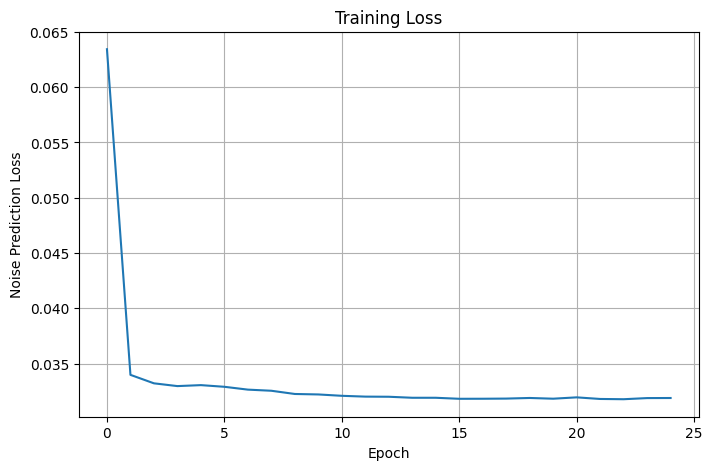

In [14]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Noise Prediction Loss")

plt.title("Training Loss")

plt.grid(True)
plt.show()

# Quantitative Evaluation

This section evaluates denoising performance using Mean Squared Error (MSE).

The following comparisons are measured:

- noisy waveform vs original waveform
- denoised waveform vs original waveform

A lower reconstruction error after denoising indicates successful corruption estimation.

In [15]:
# ========================= EVALUATION =========================

model.eval()

with torch.no_grad():

    x0 = next(iter(loader)).to(DEVICE)

    test_t = torch.full(
        (x0.shape[0],),
        diffusion_steps // 2,
        device=DEVICE
    )

    noisy, _ = get_poisson_spike_noised_sample(x0, test_t)

    pred_noise = model(noisy, test_t)

    denoised = torch.clamp(
        noisy - pred_noise,
        0.0,
        1.0
    )

    mse_noisy = F.mse_loss(noisy, x0)

    mse_denoised = F.mse_loss(denoised, x0)

print(f"\nNoisy MSE: {mse_noisy.item():.5f}")
print(f"Denoised MSE: {mse_denoised.item():.5f}")


Noisy MSE: 0.04992
Denoised MSE: 0.03147


# Forward Corruption Visualization

This section visualizes how waveform corruption changes with increasing diffusion timestep.

Larger timesteps correspond to stronger corruption levels.

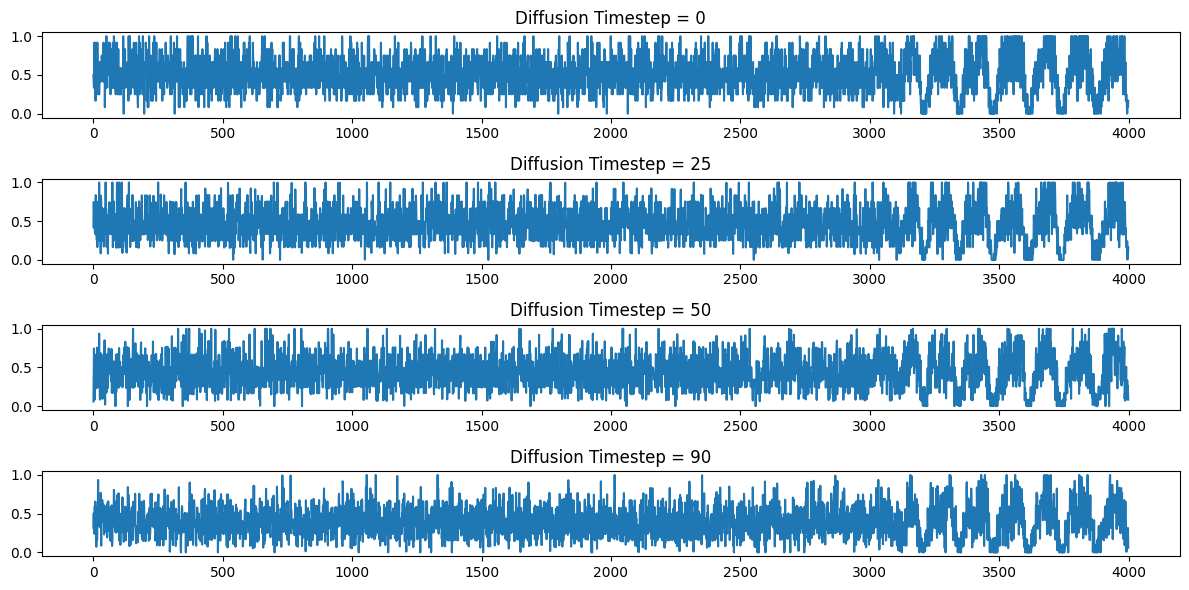

In [16]:
x0 = next(iter(loader)).to(DEVICE)

timesteps = [0, 25, 50, 90]

plt.figure(figsize=(12, 6))

for i, tval in enumerate(timesteps):

    t = torch.full(
        (x0.shape[0],),
        tval,
        device=DEVICE
    )

    noisy, _ = get_poisson_spike_noised_sample(x0, t)

    plt.subplot(len(timesteps), 1, i + 1)

    plt.plot(noisy[0].cpu().numpy())

    plt.title(f"Diffusion Timestep = {tval}")

plt.tight_layout()
plt.show()

# Qualitative Denoising Analysis

This section compares:

- original waveform
- corrupted waveform
- denoised reconstruction

The objective is to visually inspect reconstruction behavior after denoising.

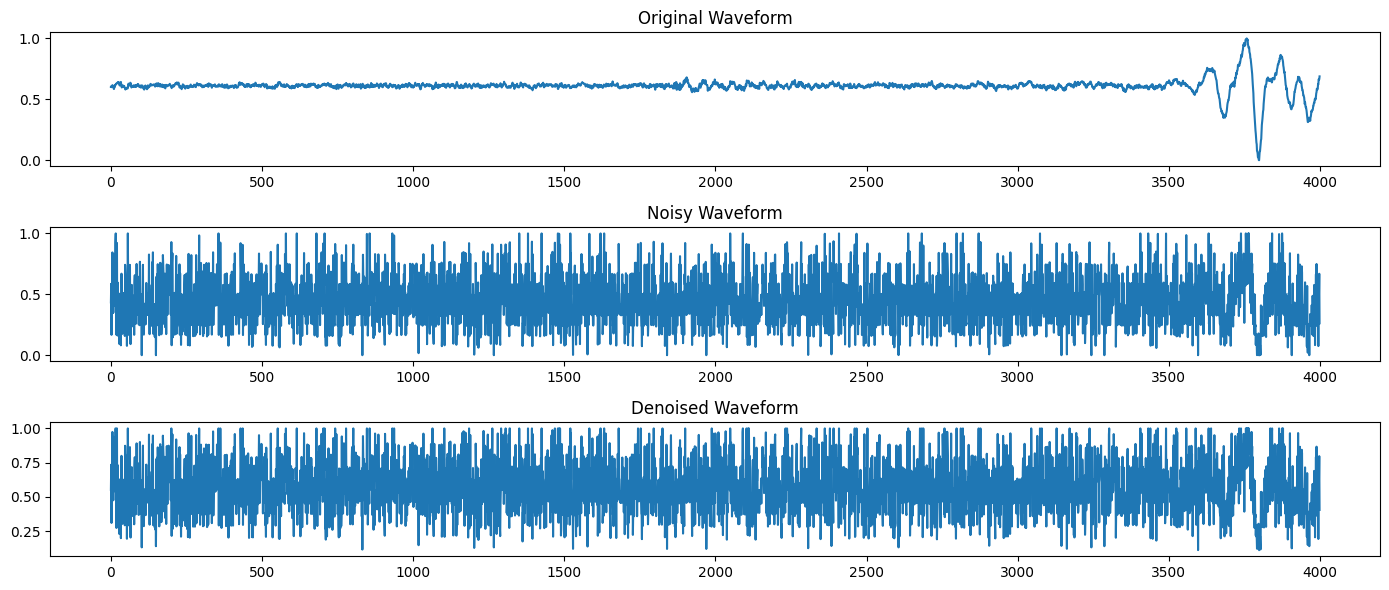

In [17]:
model.eval()

with torch.no_grad():

    x0 = next(iter(loader)).to(DEVICE)

    test_t = torch.full(
        (x0.shape[0],),
        diffusion_steps // 2,
        device=DEVICE
    )

    noisy, _ = get_poisson_spike_noised_sample(x0, test_t)

    pred_noise = model(noisy, test_t)

    denoised = torch.clamp(
        noisy - pred_noise,
        0.0,
        1.0
    )

plt.figure(figsize=(14, 6))

plt.subplot(3,1,1)
plt.plot(x0[0].cpu().numpy())
plt.title("Original Waveform")

plt.subplot(3,1,2)
plt.plot(noisy[0].cpu().numpy())
plt.title("Noisy Waveform")

plt.subplot(3,1,3)
plt.plot(denoised[0].cpu().numpy())
plt.title("Denoised Waveform")

plt.tight_layout()
plt.show()

# Conclusion

This notebook demonstrates a diffusion-inspired denoising framework using Spiking Neural Networks for audio waveform reconstruction.

## Observations

- The model learns to estimate stochastic corruption added to waveforms
- Denoised outputs achieve lower reconstruction error than noisy inputs
- Temporal spike processing can be applied to diffusion-style denoising objectives

## Limitations

- The implementation does not include iterative reverse diffusion sampling
- Reconstruction quality is limited by the small architecture and training duration
- Waveform-based fully connected processing is computationally expensive

## Possible Extensions

- convolutional SNN architectures
- spectrogram-based denoising
- iterative reverse diffusion
- alternative spike encoding schemes
- larger training datasets

## Summary

This experiment provides a spike-based implementation of diffusion-style denoising for audio waveforms and evaluates the feasibility of temporal SNN processing for stochastic corruption estimation.